# LEAF TLS Processing – Exploration Notebook

Processing pipeline for the permanent LEAF MkIII scanner at DE-Har.  
Three scan types per cycle:

| Scan type | ID | Schedule (UTC) | Resolution | Purpose |
|---|---|---|---|---|
| **hinge-hi** | scan1 | 6x/day (23,02,08,11,14,20) | 5 zenith rings x 8500 azimuths | LAI via hinge angle (57.5 deg) + PAVD |
| **hemi-low** | scan2 | 8x/day (22,01,04,07,10,13,16,19) | 100 az x 146 zen, 1.8 deg step | Fast Pgap hemisphere |
| **hemi-hi** | scan4 | 8x/day (21,00,03,06,09,12,15,18) | 400 az x 584 zen, 0.45 deg step | High-res Pgap + vertical profiles |

---

### Data format (from LEAF Operating Manual v1.4, Table 7)

| Col | Field | Description |
|-----|-------|-------------|
| 0 | **Sample count** | Sequential sample number |
| 1 | **Scan encoder** | Zenith encoder (0-25,599 per 360 deg) |
| 2 | **Rotary encoder** | Azimuth encoder (0-19,999 per 360 deg) |
| 3 | **Range first return** | Distance in metres; -1.00 or >120 = gap |
| 4 | **Intensity first return** | 0 (gap) to 100 (max reflectance), uncalibrated |
| 5 | **Range last return** | Distance in metres |
| 6 | **Intensity last return** | 0-100 |
| 7 | **Sample interval** | Time between samples in milliseconds |

**Angle conversion (MkIII):**
- Zenith angle = `(scan_encoder / 25600) * 360` (relative to scan start; needs offset to true zenith)
- Azimuth angle = `(rotary_encoder / 20000) * 360`
- Gap detection: `range == -1.00` or `range > 120`

**Header (17 rows):** `#Scan: zenith_shots, azimuth_shots, motor_steps_zenith, motor_steps_azimuth`  
**Footer (7 rows):** battery end, current, noise, lidar temp, motor temp, GPS, duration

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import re

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Parse LEAF CSV files

In [2]:
# --- Constants ---
SCAN_ENCODER_FULL = 25600   # counts per 360 deg zenith (MkIII)
ROTARY_ENCODER_FULL = 20000 # counts per 360 deg azimuth (MkIII)
GAP_RANGE_THRESHOLD = 120.0 # metres; range > this or == -1 is a gap


def parse_leaf_csv(filepath):
    """Parse a LEAF scanner CSV file.
    
    Returns
    -------
    metadata : dict
        Header + footer metadata.
    data : pd.DataFrame
        Columns per Manual Table 7, plus derived: zenith_enc_deg, azimuth_deg, is_gap
    """
    filepath = Path(filepath)
    metadata = {}
    header_lines = []
    data_lines = []
    footer_lines = []
    
    in_data = False
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('#'):
                if in_data:
                    footer_lines.append(line)
                else:
                    header_lines.append(line)
            else:
                in_data = True
                data_lines.append(line)
    
    # Parse header key:value pairs
    for hl in header_lines:
        if ':' in hl:
            key, val = hl[1:].split(':', 1)
            metadata[key.strip()] = val.strip()
    
    # Parse footer
    for fl in footer_lines:
        if ':' in fl:
            key, val = fl[1:].split(':', 1)
            metadata[f'footer_{key.strip()}'] = val.strip()
    
    # Scan config
    scan_str = metadata.get('Scan', '')
    metadata['scan_params'] = [x.strip() for x in scan_str.split(',')]
    
    # Tilt sensor (x,y,z where +/-1024 = +/-90 deg)
    tilt_str = metadata.get('Tilt', '')
    if tilt_str:
        metadata['tilt_xyz'] = [float(x) for x in tilt_str.split(',')]
    
    # Scan type and resolution from filename
    fname = filepath.name
    for st in ['hinge', 'hemi', 'ground']:
        if st in fname:
            metadata['scan_type'] = st
            break
    else:
        metadata['scan_type'] = 'unknown'
    
    res_match = re.search(r'_(\d{4})_(\d{4})\.csv$', fname)
    if res_match:
        metadata['n_zenith_shots'] = int(res_match.group(1))
        metadata['n_azimuth_shots'] = int(res_match.group(2))
    
    ts_match = re.search(r'(\d{8}-\d{6}Z)', fname)
    if ts_match:
        metadata['timestamp'] = datetime.strptime(ts_match.group(1), '%Y%m%d-%H%M%SZ')
    
    # Parse data rows
    col_names = ['sample_count', 'scan_encoder', 'rotary_encoder',
                 'range_first', 'intensity_first',
                 'range_last', 'intensity_last',
                 'sample_interval_ms']
    
    rows = []
    for dl in data_lines:
        vals = dl.split(',')
        if len(vals) == 8:
            try:
                rows.append([float(v) for v in vals])
            except ValueError:
                continue
    
    data = pd.DataFrame(rows, columns=col_names)
    
    # Derived: raw encoder degrees (before zenith offset correction)
    data['zenith_enc_deg'] = (data['scan_encoder'] / SCAN_ENCODER_FULL) * 360.0
    data['azimuth_deg'] = (data['rotary_encoder'] / ROTARY_ENCODER_FULL) * 360.0
    
    # Gap flag (Manual Table 7: range -1 or >120 = non-return)
    data['is_gap'] = ((data['range_first'] < 0) |
                      (data['range_first'] > GAP_RANGE_THRESHOLD))
    
    return metadata, data

In [4]:
# --- Load example files ---
from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[1]
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "proximal_rs" / "leaf"

# hemi_low_file = DATA_DIR / 'ESS00320_0017_hemi_20250417-001027Z_0200_0100.csv'
# hinge_file    = DATA_DIR / 'ESS00320_0018_hinge_20250417-011027Z_0005_8500.csv'
# hemi_hi_file  = DATA_DIR / 'ESS00320_0019_hemi_20250417-021030Z_0800_0400.csv'

hemi_low_file = DATA_DIR / 'ESS00320_1406_hemi_20250619-031029Z_0200_0100.csv'
hinge_file    = DATA_DIR / 'ESS00320_1409_hinge_20250619-071028Z_0005_8500.csv'
hemi_hi_file  = DATA_DIR / 'ESS00320_1407_hemi_20250619-051029Z_0800_0400.csv'

meta_hl, data_hl = parse_leaf_csv(hemi_low_file)
meta_hg, data_hg = parse_leaf_csv(hinge_file)
meta_hh, data_hh = parse_leaf_csv(hemi_hi_file)

## 2. Encoder exploration and zenith offset calibration

The scan encoder is *relative* to the scan start position. The LEAF sweeps zenith from -130 deg to +130 deg around vertical for hemi scans. The encoder midpoint of a hemi scan should correspond to true zenith (0 deg = straight up).

For hinge scans the scan head sits near 57.5 deg zenith, so the encoder value is nearly constant.

In [5]:
def explore_encoders(data, meta):
    """Print encoder range summary for a parsed scan."""
    print(f"Scan type: {meta['scan_type']}")
    print(f"Timestamp: {meta.get('timestamp', 'N/A')}")
    print(f"Scan params: {meta['scan_params']}")
    print(f"Tilt (x,y,z): {meta.get('tilt_xyz', 'N/A')}")
    print(f"N samples: {len(data)}")
    print(f"\nScan encoder:   min={data.scan_encoder.min():.0f}  max={data.scan_encoder.max():.0f}")
    print(f"  raw degrees:  {data.zenith_enc_deg.min():.1f} - {data.zenith_enc_deg.max():.1f}")
    print(f"Rotary encoder: min={data.rotary_encoder.min():.0f}  max={data.rotary_encoder.max():.0f}")
    print(f"  azimuth:      {data.azimuth_deg.min():.1f} - {data.azimuth_deg.max():.1f}")
    print(f"Range first:    min={data.range_first.min():.2f}  max={data.range_first.max():.2f}")
    print(f"Gaps: {data.is_gap.sum()} / {len(data)} ({100*data.is_gap.mean():.1f}%)")
    print()

explore_encoders(data_hl, meta_hl)
explore_encoders(data_hg, meta_hg)
explore_encoders(data_hh, meta_hh)

Scan type: hemi
Timestamp: 2025-06-19 03:10:29
Scan params: ['200', '100', '128', '100']
Tilt (x,y,z): [26.56, -24.76, 1051.58]
N samples: 14747

Scan encoder:   min=3584  max=22244
  raw degrees:  50.4 - 312.8
Rotary encoder: min=0  max=10000
  azimuth:      0.0 - 180.0
Range first:    min=0.28  max=654.36
Gaps: 544 / 14747 (3.7%)

Scan type: hinge
Timestamp: 2025-06-19 07:10:28
Scan params: ['5', '8500', '32']
Tilt (x,y,z): [26.4, -23.9, 1050.88]
N samples: 42500

Scan encoder:   min=16829  max=16957
  raw degrees:  236.7 - 238.5
Rotary encoder: min=0  max=20000
  azimuth:      0.0 - 360.0
Range first:    min=0.32  max=654.36
Gaps: 309 / 42500 (0.7%)

Scan type: hemi
Timestamp: 2025-06-19 05:10:29
Scan params: ['800', '400', '32', '25']
Tilt (x,y,z): [26.86, -24.6, 1052.78]
N samples: 234184

Scan encoder:   min=3488  max=22154
  raw degrees:  49.1 - 311.5
Rotary encoder: min=0  max=10000
  azimuth:      0.0 - 180.0
Range first:    min=0.11  max=654.36
Gaps: 10525 / 234184 (4.5%)



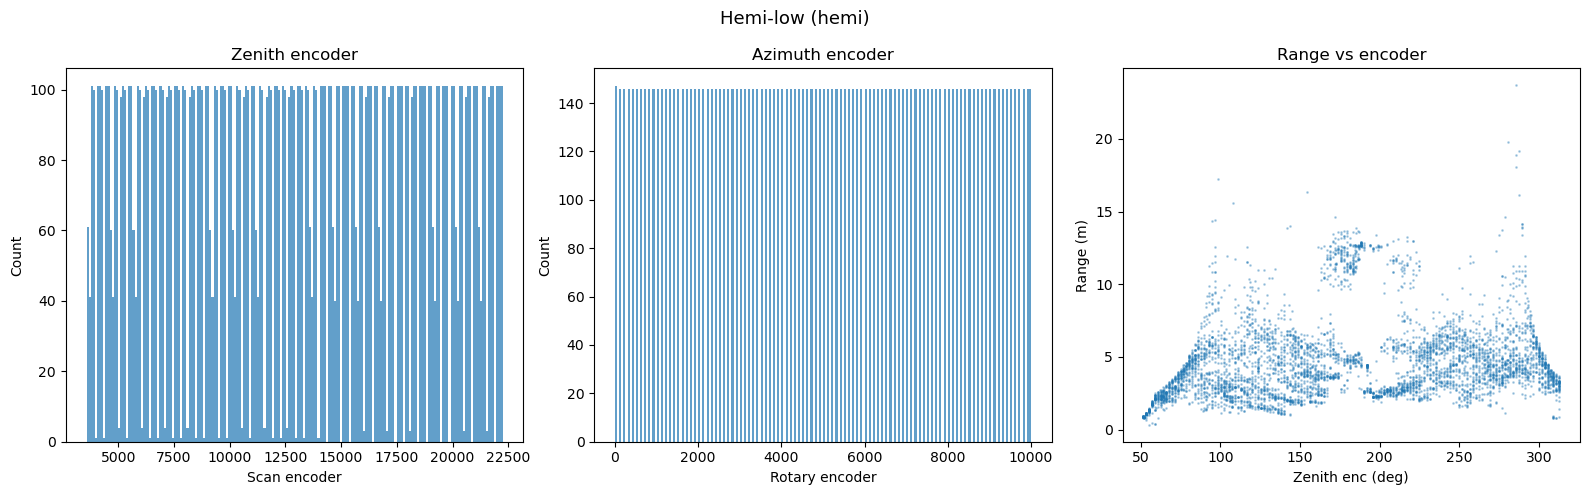

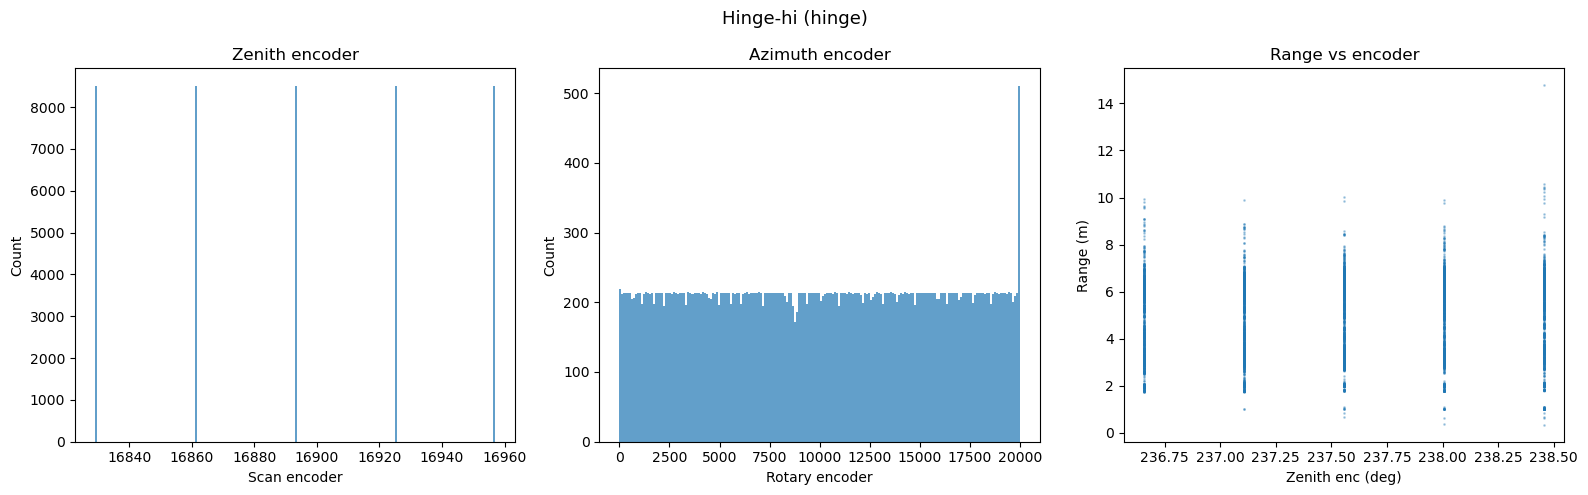

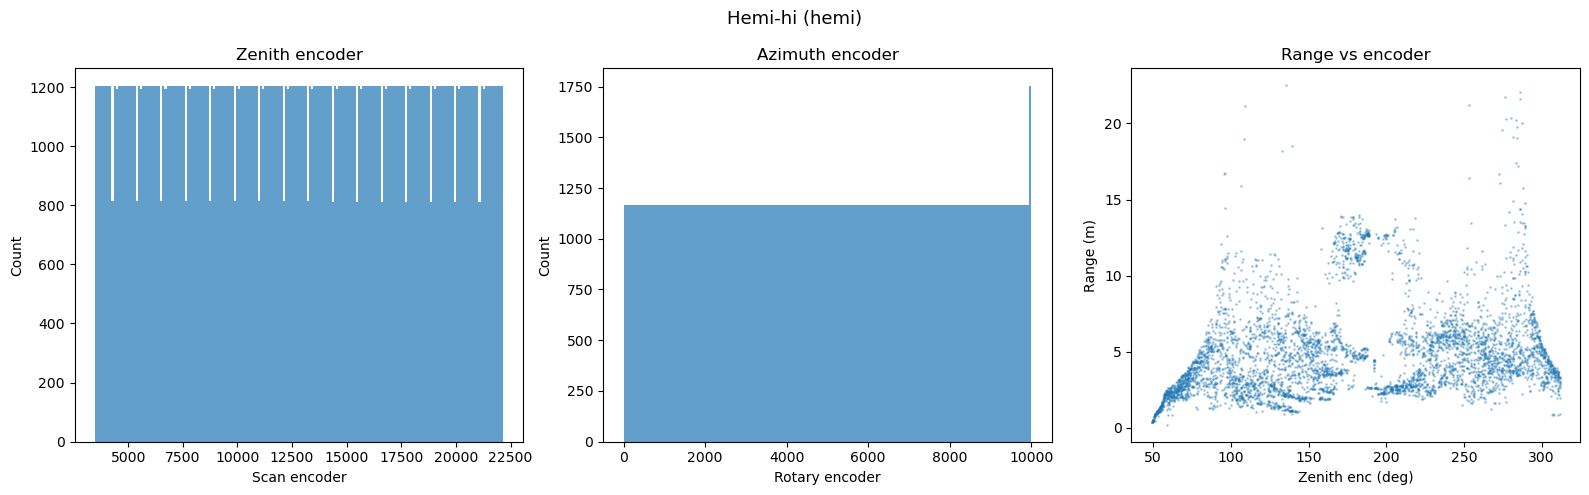

In [6]:
def plot_encoder_distribution(data, meta, title=''):
    """Visualize encoder distributions to identify zenith offset."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    axes[0].hist(data.scan_encoder, bins=200, alpha=0.7)
    axes[0].set(xlabel='Scan encoder', ylabel='Count', title='Zenith encoder')
    
    axes[1].hist(data.rotary_encoder, bins=200, alpha=0.7)
    axes[1].set(xlabel='Rotary encoder', ylabel='Count', title='Azimuth encoder')
    
    hits = data[~data.is_gap]
    if len(hits) > 5000:
        hits = hits.sample(5000)
    axes[2].scatter(hits.zenith_enc_deg, hits.range_first, s=1, alpha=0.3)
    axes[2].set(xlabel='Zenith enc (deg)', ylabel='Range (m)', title='Range vs encoder')
    
    plt.suptitle(f'{title} ({meta["scan_type"]})', fontsize=13)
    plt.tight_layout()

plot_encoder_distribution(data_hl, meta_hl, 'Hemi-low')
plot_encoder_distribution(data_hg, meta_hg, 'Hinge-hi')
plot_encoder_distribution(data_hh, meta_hh, 'Hemi-hi')

In [7]:
def calibrate_zenith_offset(data_hemi):
    """Estimate scan encoder value at true zenith (0 deg = vertical).
    
    Uses midpoint of encoder range in a hemi scan (which sweeps -130 to +130 deg).
    The span should be ~260 deg worth of encoder counts.
    """
    enc_min = data_hemi.scan_encoder.min()
    enc_max = data_hemi.scan_encoder.max()
    encoder_at_zenith0 = (enc_min + enc_max) / 2.0
    span_deg = (enc_max - enc_min) / SCAN_ENCODER_FULL * 360
    
    print(f"Encoder range: {enc_min:.0f} - {enc_max:.0f}")
    print(f"Midpoint (zenith=0): {encoder_at_zenith0:.0f}")
    print(f"Span: {enc_max - enc_min:.0f} counts = {span_deg:.1f} deg (expect ~260)")
    
    return encoder_at_zenith0


def apply_zenith_offset(data, encoder_at_zenith0):
    """Convert scan encoder to true zenith angle.
    
    zenith_deg: 0 = vertical (up), 90 = horizon, >90 = below horizon.
    Sign: positive = one side, negative = opposite side of hemisphere.
    """
    data = data.copy()
    data['zenith_deg'] = ((data['scan_encoder'] - encoder_at_zenith0)
                          / SCAN_ENCODER_FULL * 360.0)
    return data


encoder_at_zenith0 = calibrate_zenith_offset(data_hl)
data_hl = apply_zenith_offset(data_hl, encoder_at_zenith0)
data_hg = apply_zenith_offset(data_hg, encoder_at_zenith0)
data_hh = apply_zenith_offset(data_hh, encoder_at_zenith0)

# Verify: hinge should cluster around +/- 57.5 deg
print(f"Hinge zenith: {data_hg.zenith_deg.min():.1f} to {data_hg.zenith_deg.max():.1f}")

Encoder range: 3584 - 22244
Midpoint (zenith=0): 12914
Span: 18660 counts = 262.4 deg (expect ~260)
Hinge zenith: 55.1 to 56.9


## 3. Gap fraction

$$P_{gap}(\theta) = \frac{N_{gap}(\theta)}{N_{total}(\theta)}$$

where gap = `range_first < 0` or `range_first > 120`.

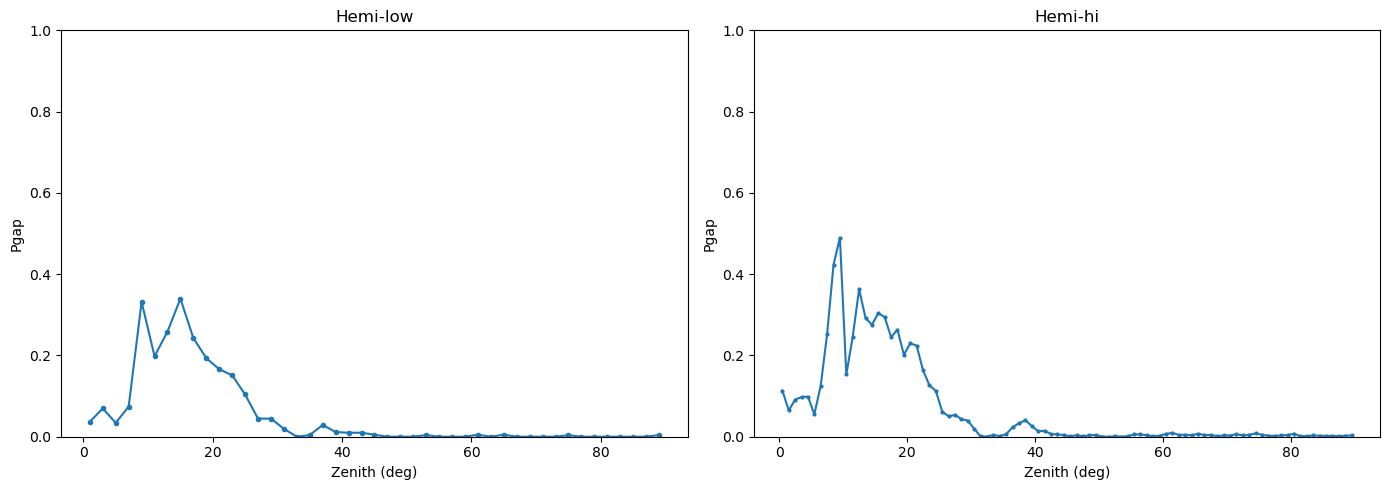

In [8]:
def compute_pgap_zenith(data, zenith_bin_width=1.0, min_zenith=0, max_zenith=90):
    """Compute gap fraction per zenith ring."""
    df = data.copy()
    df['zenith_abs'] = df['zenith_deg'].abs()
    df = df[(df.zenith_abs >= min_zenith) & (df.zenith_abs <= max_zenith)]
    
    df['zenith_bin'] = ((df['zenith_abs'] // zenith_bin_width) * zenith_bin_width
                        + zenith_bin_width / 2)
    
    grouped = df.groupby('zenith_bin').agg(
        n_total=('is_gap', 'count'),
        n_gap=('is_gap', 'sum')
    ).reset_index()
    grouped['pgap'] = grouped['n_gap'] / grouped['n_total']
    
    return grouped.rename(columns={'zenith_bin': 'zenith_center'})


pgap_hl = compute_pgap_zenith(data_hl, zenith_bin_width=2.0)
pgap_hh = compute_pgap_zenith(data_hh, zenith_bin_width=1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(pgap_hl.zenith_center, pgap_hl.pgap, 'o-', ms=3)
axes[0].set(xlabel='Zenith (deg)', ylabel='Pgap', title='Hemi-low', ylim=(0,1))
axes[1].plot(pgap_hh.zenith_center, pgap_hh.pgap, 'o-', ms=2)
axes[1].set(xlabel='Zenith (deg)', ylabel='Pgap', title='Hemi-hi', ylim=(0,1))
plt.tight_layout()

## 4. PAI estimation

**Miller's formula** (hemi scans, numerical integration over zenith):
$$PAI = 2 \int_0^{\pi/2} -\ln(P_{gap}(\theta)) \cos\theta \sin\theta \, d\theta$$

**Hinge angle** (57.5 deg, Jupp et al. 2009):  $PAI \approx -\ln(P_{gap}(57.5°))$

In [9]:
def compute_pai_miller(pgap_df, min_zenith=5, max_zenith=70):
    """PAI via Miller's formula."""
    df = pgap_df[(pgap_df.zenith_center >= min_zenith) &
                  (pgap_df.zenith_center <= max_zenith)]
    theta = np.deg2rad(df.zenith_center.values)
    pgap = np.clip(df.pgap.values, 1e-6, 1.0)
    integrand = -np.log(pgap) * np.cos(theta) * np.sin(theta)
    return 2 * np.trapezoid(integrand, theta)


def compute_pai_hinge(data, target_zenith=57.5, tolerance=2.0):
    """PAI from hinge scan at 57.5 deg."""
    mask = (data['zenith_deg'].abs() - target_zenith).abs() < tolerance
    subset = data[mask]
    if len(subset) == 0:
        return np.nan, np.nan
    pgap = subset.is_gap.mean()
    pgap = max(pgap, 1e-6)
    return -np.log(pgap), pgap


pai_hl = compute_pai_miller(pgap_hl)
pai_hinge, pgap_hinge = compute_pai_hinge(data_hg)
print(f'PAI hemi-low (Miller): {pai_hl:.2f}')
print(f'PAI hinge (57.5 deg):  {pai_hinge:.2f}  (Pgap={pgap_hinge:.3f})')

PAI hemi-low (Miller): 6.15
PAI hinge (57.5 deg):  4.75  (Pgap=0.009)


## 5. Vertical profiles (PAVD)

Height of return: $h = r \cdot \cos(\theta)$

Stratify gap fraction by height, then differentiate cumulative PAI.

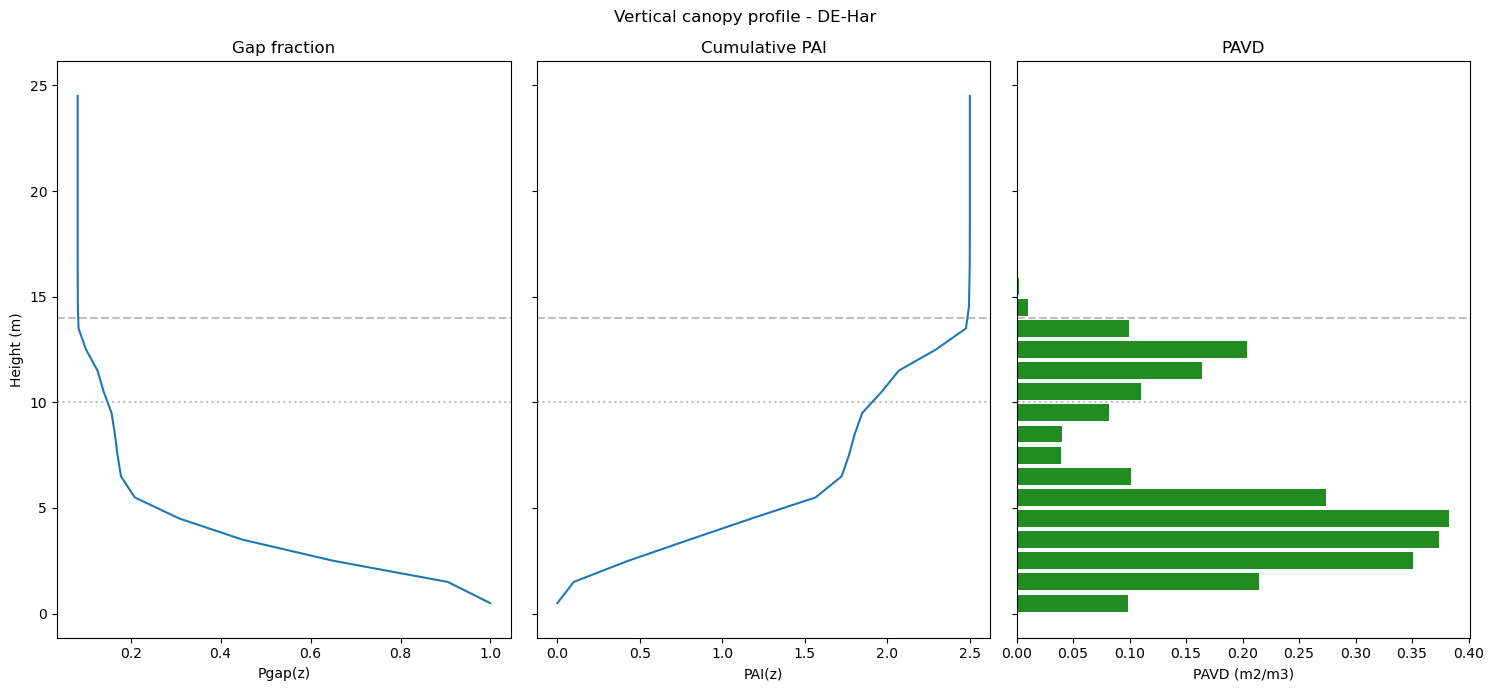

In [10]:
def compute_pavd_profile(data, height_bin=1.0, min_zenith=5, max_zenith=70,
                         max_height=25):
    """Simplified PAVD profile from hemi scan.
    
    NOTE: Does not include occlusion correction. Validate against
    pylidar_plantprofile for production use.
    """
    df = data.copy()
    df['zenith_abs'] = df['zenith_deg'].abs()
    df = df[(df.zenith_abs >= min_zenith) & (df.zenith_abs <= max_zenith)]
    
    # Height of first return (valid returns only)
    valid = df[~df.is_gap].copy()
    valid['height'] = valid['range_first'] * np.cos(np.deg2rad(valid['zenith_abs']))
    
    n_total = len(df)
    n_gaps = df.is_gap.sum()
    
    heights = np.arange(0, max_height, height_bin) + height_bin / 2
    pgap_z = np.zeros(len(heights))
    
    for i, h in enumerate(heights):
        # Samples seeing through height h = complete gaps + returns above h
        n_pass = n_gaps + (valid['height'] > h).sum()
        pgap_z[i] = n_pass / n_total if n_total > 0 else 1.0
    
    pgap_z = np.clip(pgap_z, 1e-6, 1.0)
    pai_z = -np.log(pgap_z)
    pavd = np.gradient(pai_z, height_bin)
    
    return pd.DataFrame({'height': heights, 'pgap_z': pgap_z,
                          'pai_z': pai_z, 'pavd': pavd})


profile = compute_pavd_profile(data_hh, height_bin=1.0)
fig, axes = plt.subplots(1, 3, figsize=(15, 7), sharey=True)
axes[0].plot(profile.pgap_z, profile.height)
axes[0].set(xlabel='Pgap(z)', ylabel='Height (m)', title='Gap fraction')
axes[1].plot(profile.pai_z, profile.height)
axes[1].set(xlabel='PAI(z)', title='Cumulative PAI')
axes[2].barh(profile.height, profile.pavd, height=0.8, color='forestgreen')
axes[2].set(xlabel='PAVD (m2/m3)', title='PAVD')
for ax in axes:
    ax.axhline(14, color='grey', ls='--', alpha=0.5)
    ax.axhline(10, color='grey', ls=':', alpha=0.5)
plt.suptitle('Vertical canopy profile - DE-Har')
plt.tight_layout()

## 6. Hemispherical projection plot

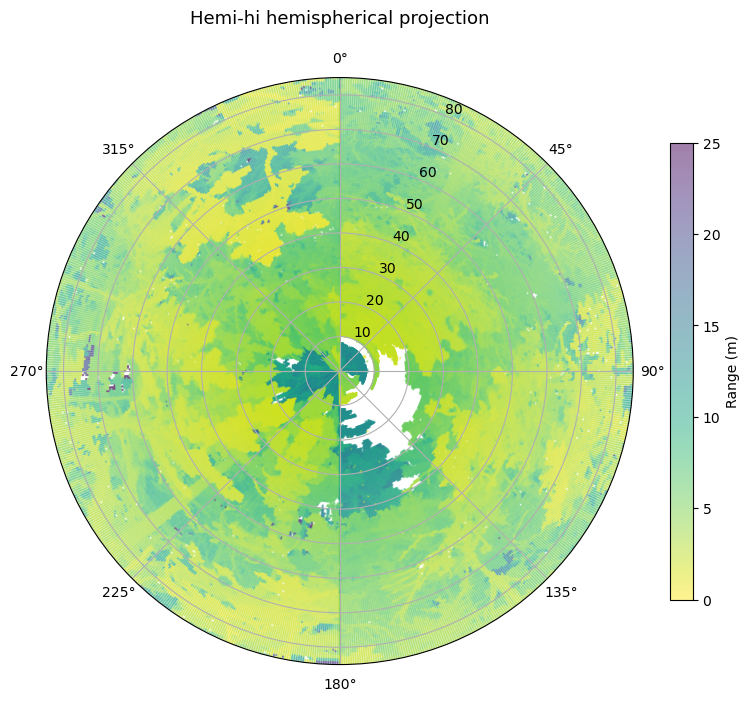

In [11]:
def plot_hemisphere(data, max_zenith=90, title=''):
    """Polar hemispherical projection. Radius = zenith, angle = azimuth.
    
    For hemi scans (0-180 deg azimuth, +/-130 deg zenith):
    negative zenith maps to azimuth + 180 deg.
    """
    df = data.copy()
    df['zenith_abs'] = df['zenith_deg'].abs()
    df = df[df.zenith_abs <= max_zenith]
    
    df['plot_az'] = np.where(
        df['zenith_deg'] >= 0,
        df['azimuth_deg'],
        (df['azimuth_deg'] + 180) % 360
    )
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    
    range_vals = df['range_first'].copy()
    range_vals[df.is_gap] = np.nan
    
    sc = ax.scatter(np.deg2rad(df['plot_az']), df['zenith_abs'],
                    c=range_vals, s=0.5, cmap='viridis_r',
                    vmin=0, vmax=25, alpha=0.5)
    ax.set_ylim(0, max_zenith)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(title, pad=20, fontsize=13)
    plt.colorbar(sc, ax=ax, label='Range (m)', shrink=0.6)
    plt.tight_layout()

plot_hemisphere(data_hh, max_zenith=85, title='Hemi-hi hemispherical projection')

## 7. Batch processing

In [26]:
def batch_process_leaf(data_dir, scan_type='hemi', encoder_at_zenith0=None):
    """Batch process all LEAF files of a given type."""
    data_dir = Path(data_dir)
    files = sorted(data_dir.glob(f'*_{scan_type}_*.csv'))
    print(f'Found {len(files)} {scan_type} files')
    
    if encoder_at_zenith0 is None:
        raise ValueError('Calibrate encoder_at_zenith0 from a hemi scan first.')
    
    records = []
    for f in files:
        try:
            meta, data = parse_leaf_csv(f)
            data = apply_zenith_offset(data, encoder_at_zenith0)
            
            if scan_type == 'hinge':
                pai, pgap = compute_pai_hinge(data)
            else:
                pgap_df = compute_pgap_zenith(data, zenith_bin_width=2.0)
                pai = compute_pai_miller(pgap_df)
                pgap = np.nan
            
            records.append({
                'datetime': meta.get('timestamp'),
                'pai': pai,
                'n_samples': len(data),
                'gap_frac_total': data.is_gap.mean(),
                'filename': f.name,
                'tilt_x': meta.get('tilt_xyz', [np.nan]*3)[0],
                'tilt_y': meta.get('tilt_xyz', [np.nan]*3)[1],
                'encl_temp': float(meta.get('Encl. Temp', '0').replace(' C', '')),
                'encl_rh': float(meta.get('Encl. humidity', '0').replace(' %', '')),
                'motor_temp': float(meta.get('footer_Motor Temp',
                                    meta.get('Motor Temp', '0')).replace(' C', '')),
            })
        except Exception as e:
            print(f'  Error {f.name}: {e}')
    
    return pd.DataFrame(records).set_index('datetime').sort_index()

## 8. Quality diagnostics

From Manual Sections 10.1 and 13:
- **Optical fouling**: gradual PAI/height decline -> track; clean optics monthly
- **Rain/wind**: outliers in PAI -> flag via met data (Culvenor et al. 2014)
- **Motor temp**: <65 C nominal, fault at 85 C
- **Tilt**: +/-1024 counts = +/-90 deg; sudden jumps = disturbance
- **Enclosure RH**: <50% target; rising = desiccant needs replacing
- **Intensity at range**: uncalibrated and not corrected for 1/r^2 falloff

In [27]:
EXPECTED_SAMPLES = {
    'hemi-low': 14600,
    'hemi-med': 58400,
    'hemi-hi': 233600,
    'hinge-low': 8500,
    'hinge-med': 25500,
    'hinge-hi': 42500,
}

def quality_flags(ts_df):
    """Add quality flag columns."""
    flags = pd.DataFrame(index=ts_df.index)
    flags['high_temp'] = ts_df.encl_temp > 45
    flags['high_motor_temp'] = ts_df.motor_temp > 65
    flags['high_humidity'] = ts_df.encl_rh > 50
    flags['tilt_jump'] = ((ts_df.tilt_x.diff().abs() > 20) |
                          (ts_df.tilt_y.diff().abs() > 20))
    med = ts_df.pai.rolling(24, center=True, min_periods=6).median()
    std = ts_df.pai.rolling(24, center=True, min_periods=6).std()
    flags['pai_outlier'] = (ts_df.pai - med).abs() > 2 * std
    return flags

## 9. Validation against pylidar-tls-canopy

```bash
pylidar_plantprofile -i scan_file.csv -o profile.csv \
    --minzenith 5 --maxzenith 70 \
    --heightbinsize 0.5 --minheight 0 --maxheight 25
```

Key validation points:
1. Does pylidar derive the same zenith angles from encoders?
2. Same gap threshold (-1 or >120 m)?
3. How does it handle the +/-130 deg sweep + 0-180 deg azimuth?
4. Occlusion correction method for height-stratified profiles?

In [51]:
from pylidar_tls_canopy import plant_profile

vpp = plant_profile.Jupp2009(
    hres=0.5,        # height_resolution
    zres=5,          # zenith_resolution (default)
    ares=45,         # azimuth_resolution (default)
    min_z=0,         # min_zenith
    max_z=70,        # max_zenith
    min_h=0,         # min_height
    max_h=30,        # max_height
)

vpp.add_leaf_scan_position(
    str(DATA_DIR / "ESS00320_0019_hemi_20250417-021030Z_0800_0400.csv"),
    method="WEIGHTED",
    min_zenith=5,
    max_zenith=70,
    sensor_height=1.5,
)

vpp.get_pgap_theta_z()
vpp.exportPlantProfiles(outfile="profile.csv")
vpp.exportPgapProfiles(outfile="pgap.csv")

In [53]:
pgap_out

,Height,Zenith0025,Zenith0075,Zenith0125,Zenith0175,Zenith0225,Zenith0275,Zenith0325,Zenith0375,Zenith0425,Zenith0475,Zenith0525,Zenith0575,Zenith0625,Zenith0675
0,0.0,NaN,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
1,0.5,NaN,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
2,1.0,NaN,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
3,1.5,NaN,0.99922,0.99928,0.99926,0.99983,0.99966,0.99961,0.99949,0.99949,0.99892,0.99883,0.99865,0.99875,0.99887
4,2.0,NaN,0.99608,0.99669,0.99694,0.99773,0.99785,0.99804,0.99775,0.99847,0.99762,0.99822,0.99266,0.96762,0.90198
5,2.5,NaN,0.99524,0.99613,0.99614,0.99648,0.99677,0.99627,0.98670,0.98228,0.97558,0.96392,0.93714,0.83712,0.76406
6,3.0,NaN,0.99376,0.99551,0.99558,0.99642,0.97529,0.95146,0.90724,0.90910,0.91692,0.87625,0.85955,0.71282,0.61072
7,3.5,NaN,0.93606,0.94562,0.94114,0.94252,0.90096,0.88656,0.87219,0.85038,0.80743,0.77344,0.74143,0.57866,0.43732
8,4.0,NaN,0.91721,0.87971,0.85646,0.85040,0.81005,0.79200,0.79750,0.77829,0.73978,0.68523,0.62826,0.41897,0.32439
9,4.5,NaN,0.91375,0.86916,0.83829,0.80097,0.74436,0.71047,0.70368,0.68064,0.66502,0.56008,0.45399,0.31757,0.25069


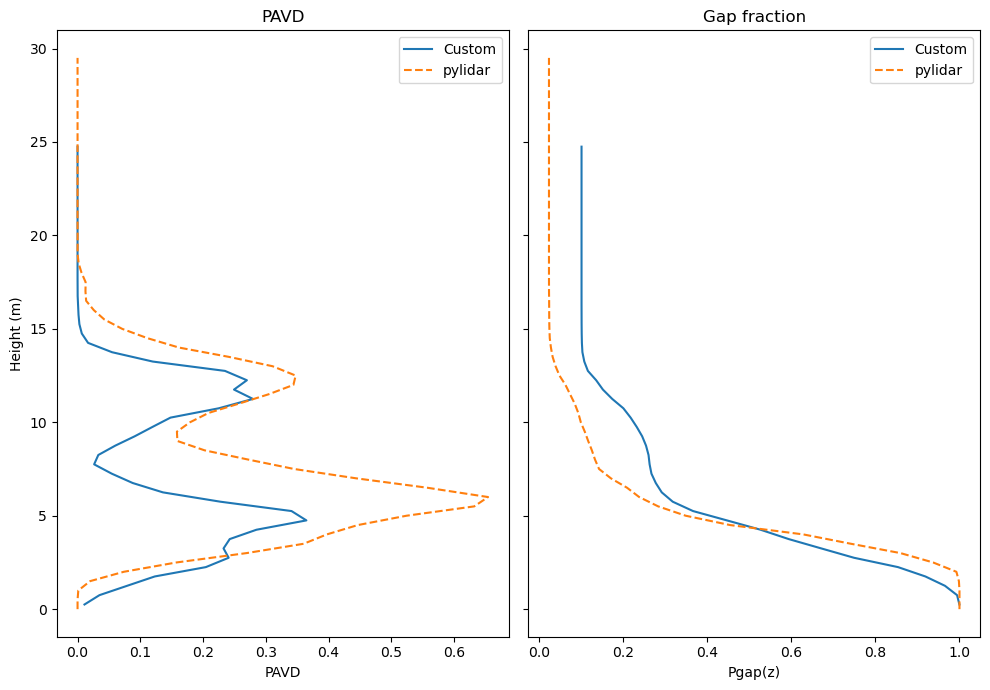

In [55]:
pylidar_out = pd.read_csv("/mnt/data/lk1167/projects/dehar-spac/notebooks/00_exploration/profile.csv")
pgap_out = pd.read_csv("/mnt/data/lk1167/projects/dehar-spac/notebooks/00_exploration/pgap.csv")
custom = compute_pavd_profile(data_hh, height_bin=0.5, max_height=25)

fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
axes[0].plot(custom.pavd, custom.height, label='Custom')
axes[0].plot(pylidar_out.WeightedPAVD, pylidar_out.Height, '--', label='pylidar')
axes[0].set(xlabel='PAVD', ylabel='Height (m)', title='PAVD')
axes[0].legend()
axes[1].plot(custom.pgap_z, custom.height, label='Custom')
axes[1].plot(pgap_out.Zenith0575, pylidar_out.Height, '--', label='pylidar')
axes[1].set(xlabel='Pgap(z)', title='Gap fraction')
axes[1].legend()
plt.tight_layout()

## Next steps

1. **Calibrate zenith offset** from a hemi scan; verify hinge clusters at 57.5 deg
2. **Validate against pylidar-tls-canopy** on sample files
3. **Height-layer PAI** - integrate PAVD over overstory (14-19 m) and understory (2-10 m)
4. **Deseasonalization** - smooth spline on non-stressed period for deciduous understory
5. **VOD structural correction** - regress nVOD against LEAF PAI
6. **PELT changepoints** on height-integrated PAI, aligned with SWP anchors
7. **Wet canopy filter** - cross-reference precip/RH to flag rain-affected scans